# Notebook 09 — Priority Prediction

Week 3 experiment: combine TF-IDF text features with engineered structured features,
then compare LinearSVC, Random Forest, and XGBoost for priority prediction.

**Hypothesis:** structured metadata (channel, product, task type, customer age) adds signal
beyond text alone, enabling a tree-based model to beat the Week 2 LinearSVC text-only
baseline of 27.3%.

**Key design decision — Ticket Status excluded:**  
Ticket Status reflects the state of a ticket *after* handling. In production, priority is
predicted at ticket creation time when status is always Open. Including Closed status would
be data leakage — the model would see information that does not exist at inference time.
Ticket Status is therefore excluded from all feature matrices.

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed — pip install xgboost to enable it')

os.makedirs('../models',          exist_ok=True)
os.makedirs('../data/processed',  exist_ok=True)
os.makedirs('../reports',         exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

print('Imports OK')

Imports OK


## Step 1 — Load Saved Artefacts and Verify Alignment

Load the saved TF-IDF matrices and label arrays from notebook 05.  
The alignment requirement: row *i* in the TF-IDF matrix must correspond to the same
ticket as row *i* in the structured feature matrix.  
The label CSVs carry the original DataFrame indices — use these to slice the cleaned
CSV, guaranteeing row-for-row correspondence.

In [2]:
X_train_tfidf = sp.load_npz('../data/processed/X_train_tfidf.npz')
X_test_tfidf  = sp.load_npz('../data/processed/X_test_tfidf.npz')

y_train_priority = pd.read_csv('../data/processed/y_train_priority.csv', index_col=0)['priority']
y_test_priority  = pd.read_csv('../data/processed/y_test_priority.csv',  index_col=0)['priority']
y_train_type     = pd.read_csv('../data/processed/y_train_type.csv',     index_col=0)['task_type']
y_test_type      = pd.read_csv('../data/processed/y_test_type.csv',      index_col=0)['task_type']

train_idx = y_train_priority.index.tolist()
test_idx  = y_test_priority.index.tolist()

df_full = pd.read_csv('../data/processed/cleaned_tasks.csv')

assert X_train_tfidf.shape[0] == len(train_idx), 'Train size mismatch'
assert X_test_tfidf.shape[0]  == len(test_idx),  'Test size mismatch'
assert sp.issparse(X_train_tfidf), 'Expected sparse TF-IDF matrix'

print(f'X_train_tfidf : {X_train_tfidf.shape}   sparse={sp.issparse(X_train_tfidf)}')
print(f'X_test_tfidf  : {X_test_tfidf.shape}   sparse={sp.issparse(X_test_tfidf)}')
print(f'y_train_priority — shape: {y_train_priority.shape}  classes: {sorted(y_train_priority.unique())}')
print(f'y_test_priority  — shape: {y_test_priority.shape}   classes: {sorted(y_test_priority.unique())}')
print(f'df_full rows: {len(df_full)}')
print(f'Train indices (first 5): {train_idx[:5]}')
print(f'Test  indices (first 5): {test_idx[:5]}')

X_train_tfidf : (6461, 1306)   sparse=True
X_test_tfidf  : (1616, 1306)   sparse=True
y_train_priority — shape: (6461,)  classes: ['critical', 'high', 'low', 'medium']
y_test_priority  — shape: (1616,)   classes: ['critical', 'high', 'low', 'medium']
df_full rows: 8077
Train indices (first 5): [6538, 7174, 7557, 2494, 480]
Test  indices (first 5): [3794, 7826, 1581, 3614, 5091]


## Step 2 — Structured Feature Engineering

| Column | Type | Encoding | Reason |
|---|---|---|---|
| Ticket Channel | Nominal (4 values) | One-hot | No natural ordering; phone may correlate with urgency |
| Product Purchased | Nominal (42 values) | One-hot | Specific products may have known priority patterns |
| Customer Age | Numeric 18–70 | Pass-through | Trees split on thresholds — scaling not needed |
| Ticket Type | Nominal (5 values) | One-hot | Ground-truth label; type-priority correlation tested |
| Ticket Status | — | **Excluded** | Data leakage — status unknown at creation time |

One `OneHotEncoder` fitted on the **train split only** encodes both train and test.  
Fitting on all data would leak test-set category frequencies into the encoder.

In [3]:
STRUCT_COLS = ['Ticket Channel', 'Product Purchased', 'Ticket Type']
NUM_COLS    = ['Customer Age']

df_train = df_full.loc[train_idx].copy()
df_test  = df_full.loc[test_idx].copy()

assert len(df_train) == len(train_idx), 'Train slice length mismatch'
assert len(df_test)  == len(test_idx),  'Test slice length mismatch'

ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
ohe.fit(df_train[STRUCT_COLS])

S_train_cat = ohe.transform(df_train[STRUCT_COLS])
S_test_cat  = ohe.transform(df_test[STRUCT_COLS])

S_train_num = sp.csr_matrix(df_train[NUM_COLS].values.astype(float))
S_test_num  = sp.csr_matrix(df_test[NUM_COLS].values.astype(float))

S_train = sp.hstack([S_train_cat, S_train_num], format='csr')
S_test  = sp.hstack([S_test_cat,  S_test_num],  format='csr')

cat_feature_names    = ohe.get_feature_names_out(STRUCT_COLS).tolist()
struct_feature_names = cat_feature_names + NUM_COLS

print(f'Categorical OHE features : {len(cat_feature_names)}')
print(f'Numeric features         : {len(NUM_COLS)}')
print(f'Total structured features: {len(struct_feature_names)}')
print(f'S_train shape: {S_train.shape}')
print(f'S_test  shape: {S_test.shape}')
print(f'\nSample OHE features (first 6): {cat_feature_names[:6]}')

Categorical OHE features : 51
Numeric features         : 1
Total structured features: 52
S_train shape: (6461, 52)
S_test  shape: (1616, 52)

Sample OHE features (first 6): ['Ticket Channel_Chat', 'Ticket Channel_Email', 'Ticket Channel_Phone', 'Ticket Channel_Social media', 'Product Purchased_Adobe Photoshop', 'Product Purchased_Amazon Echo']


## Step 3 — Combine TF-IDF and Structured Features

Horizontal stack places structured feature columns directly after TF-IDF columns in each row.  
Both matrices are sparse — `scipy.sparse.hstack` preserves sparsity without converting to dense.  
The combined feature name list (saved in Step 9) maps each column index back to its original feature.

In [4]:
vectorizer          = joblib.load('../models/tfidf_vectorizer.pkl')
tfidf_feature_names = vectorizer.get_feature_names_out().tolist()

X_train_combined = sp.hstack([X_train_tfidf, S_train], format='csr')
X_test_combined  = sp.hstack([X_test_tfidf,  S_test],  format='csr')

all_feature_names = tfidf_feature_names + struct_feature_names

n_tfidf      = len(tfidf_feature_names)
n_structured = len(struct_feature_names)

print(f'TF-IDF features    : {n_tfidf}')
print(f'Structured features: {n_structured}')
print(f'Combined features   : {len(all_feature_names)}')
print(f'X_train_combined shape: {X_train_combined.shape}  match={X_train_combined.shape[1] == len(all_feature_names)}')
print(f'X_test_combined  shape: {X_test_combined.shape}')
assert X_train_combined.shape[1] == len(all_feature_names), 'Feature name list length mismatch'

TF-IDF features    : 1306
Structured features: 52
Combined features   : 1358
X_train_combined shape: (6461, 1358)  match=True
X_test_combined  shape: (1616, 1358)


## Step 4 — Baseline Comparisons

Three reference points before training tree models:

| Baseline | Accuracy | Notes |
|---|---|---|
| Random (4 balanced classes) | 25.0% | Theoretical floor |
| LinearSVC text-only (Week 2) | 27.3% | Beating this validates structured features add signal |
| LinearSVC text + structured | measured below | Isolates structured contribution from model choice |

**Experimental logic:** if LinearSVC+combined beats LinearSVC+text, structured features contribute signal.  
If Random Forest then beats LinearSVC+combined, the non-linear model adds further value.

In [5]:
WEEK2_TEXT_ONLY_ACC = 0.273
RANDOM_BASELINE_ACC = 0.250

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_priority)
y_test_enc  = le.transform(y_test_priority)
print(f'Priority classes: {le.classes_}')

results = {}

results['Random (4 classes)'] = {
    'accuracy': RANDOM_BASELINE_ACC,
    'macro_f1': RANDOM_BASELINE_ACC,
    'features': 'theoretical'
}

results['LinearSVC — text only (Week 2)'] = {
    'accuracy': WEEK2_TEXT_ONLY_ACC,
    'macro_f1': None,
    'features': 'text only'
}

svc_combined = LinearSVC(C=0.5, max_iter=2000, random_state=42)
svc_combined.fit(X_train_combined, y_train_priority)
svc_comb_pred = svc_combined.predict(X_test_combined)

svc_comb_acc = accuracy_score(y_test_priority, svc_comb_pred)
svc_comb_f1  = f1_score(y_test_priority, svc_comb_pred, average='macro')

results['LinearSVC — text + structured'] = {
    'accuracy': svc_comb_acc,
    'macro_f1': svc_comb_f1,
    'features': 'text + structured'
}

print(f'\nLinearSVC combined  accuracy: {svc_comb_acc:.4f}  macro F1: {svc_comb_f1:.4f}')
print(f'vs Week 2 baseline: {(svc_comb_acc - WEEK2_TEXT_ONLY_ACC)*100:+.1f} pp')
print()
print(classification_report(y_test_priority, svc_comb_pred, digits=3))

Priority classes: ['critical' 'high' 'low' 'medium']

LinearSVC combined  accuracy: 0.2642  macro F1: 0.2629
vs Week 2 baseline: -0.9 pp

              precision    recall  f1-score   support

    critical      0.256     0.241     0.248       399
        high      0.270     0.265     0.268       415
         low      0.245     0.233     0.238       387
      medium      0.281     0.316     0.297       415

    accuracy                          0.264      1616
   macro avg      0.263     0.263     0.263      1616
weighted avg      0.263     0.264     0.263      1616



## Step 5 — Random Forest Experiments

Random Forest builds many decision trees on random data and feature subsets, then votes.  
Individual trees overfit; the ensemble averages that overfitting away.

| Parameter | Values | Rationale |
|---|---|---|
| `n_estimators` | 100, 200 | 100 for speed; 200 for stability |
| `max_depth` | None, 10, 20 | None = full growth; limits control regularisation |
| `min_samples_leaf` | 1, 5, 10 | Critical on noisy template-contaminated data |
| `class_weight` | balanced | Handles slight class imbalance |
| `random_state` | 42 | Reproducibility |

In [6]:
rf_grid = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 100, 'max_depth': 10,   'min_samples_leaf': 5},
    {'n_estimators': 100, 'max_depth': 20,   'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 20,   'min_samples_leaf': 10},
]

rf_results = []
for params in rf_grid:
    rf = RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_combined, y_train_priority)
    pred      = rf.predict(X_test_combined)
    acc       = accuracy_score(y_test_priority, pred)
    mf1       = f1_score(y_test_priority, pred, average='macro')
    train_acc = accuracy_score(y_train_priority, rf.predict(X_train_combined))
    rf_results.append({
        'n_estimators': params['n_estimators'],
        'max_depth': str(params['max_depth']),
        'min_samples_leaf': params['min_samples_leaf'],
        'train_acc': train_acc,
        'test_acc': acc,
        'macro_f1': mf1,
        'gap': train_acc - acc,
        'model_obj': rf
    })
    d = str(params['max_depth'])
    print(f"n_est={params['n_estimators']:3d}  depth={d:4s}  "
          f"leaf={params['min_samples_leaf']:2d}  "
          f"train={train_acc:.4f}  test={acc:.4f}  F1={mf1:.4f}  gap={train_acc-acc:.4f}")

best_rf_row = max(rf_results, key=lambda r: r['test_acc'])
best_rf     = best_rf_row['model_obj']
print(f"\nBest RF: n_est={best_rf_row['n_estimators']} depth={best_rf_row['max_depth']} "
      f"leaf={best_rf_row['min_samples_leaf']} -> test acc={best_rf_row['test_acc']:.4f}")

results['Random Forest (best)'] = {
    'accuracy': best_rf_row['test_acc'],
    'macro_f1': best_rf_row['macro_f1'],
    'features': 'text + structured'
}

n_est=100  depth=None  leaf= 1  train=1.0000  test=0.2543  F1=0.2541  gap=0.7457
n_est=100  depth=10    leaf= 5  train=0.4718  test=0.2537  F1=0.2511  gap=0.2180
n_est=100  depth=20    leaf= 5  train=0.5727  test=0.2531  F1=0.2516  gap=0.3196
n_est=200  depth=None  leaf= 5  train=0.8686  test=0.2512  F1=0.2513  gap=0.6174
n_est=200  depth=20    leaf=10  train=0.5185  test=0.2327  F1=0.2324  gap=0.2858

Best RF: n_est=100 depth=None leaf=1 -> test acc=0.2543


## Step 6 — XGBoost Experiments

XGBoost builds trees sequentially — each tree corrects residual errors of the previous ensemble.  
More powerful than Random Forest but more sensitive to hyperparameters and prone to overfitting on noisy data.

**Early stopping strategy:** train on 90% of training data, validate on 10%, stop when validation loss
stops improving for 30 rounds. This eliminates the need to hand-tune `n_estimators`.

In [7]:
if XGB_AVAILABLE:
    from sklearn.model_selection import train_test_split

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_combined, y_train_enc,
        test_size=0.1, random_state=42, stratify=y_train_enc
    )

    xgb_grid = [
        {'max_depth': 4, 'learning_rate': 0.1,  'subsample': 0.8, 'colsample_bytree': 0.8},
        {'max_depth': 6, 'learning_rate': 0.1,  'subsample': 0.8, 'colsample_bytree': 0.7},
        {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    ]

    xgb_results = []
    for params in xgb_grid:
        clf = xgb.XGBClassifier(
            **params,
            n_estimators=500,
            objective='multi:softmax',
            num_class=4,
            eval_metric='mlogloss',
            early_stopping_rounds=30,
            use_label_encoder=False,
            random_state=42,
            n_jobs=-1
        )
        clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred_enc    = clf.predict(X_test_combined)
        pred_labels = le.inverse_transform(pred_enc)
        acc = accuracy_score(y_test_priority, pred_labels)
        mf1 = f1_score(y_test_priority, pred_labels, average='macro')
        xgb_results.append({
            'max_depth': params['max_depth'],
            'lr':  params['learning_rate'],
            'col': params['colsample_bytree'],
            'best_iter': clf.best_iteration,
            'test_acc': acc,
            'macro_f1': mf1,
            'model_obj': clf
        })
        print(f"depth={params['max_depth']}  lr={params['learning_rate']}  col={params['colsample_bytree']}  "
              f"best_iter={clf.best_iteration}  test_acc={acc:.4f}  F1={mf1:.4f}")

    best_xgb_row = max(xgb_results, key=lambda r: r['test_acc'])
    best_xgb     = best_xgb_row['model_obj']
    print(f"\nBest XGB: depth={best_xgb_row['max_depth']} lr={best_xgb_row['lr']} "
          f"iter={best_xgb_row['best_iter']} -> test acc={best_xgb_row['test_acc']:.4f}")

    results['XGBoost (best)'] = {
        'accuracy': best_xgb_row['test_acc'],
        'macro_f1': best_xgb_row['macro_f1'],
        'features': 'text + structured'
    }
else:
    print('XGBoost skipped — not installed')
    best_xgb = None

depth=4  lr=0.1  col=0.8  best_iter=41  test_acc=0.2568  F1=0.2512
depth=6  lr=0.1  col=0.7  best_iter=46  test_acc=0.2587  F1=0.2555
depth=4  lr=0.05  col=0.8  best_iter=56  test_acc=0.2574  F1=0.2424

Best XGB: depth=6 lr=0.1 iter=46 -> test acc=0.2587


## Step 7 — Feature Importance Analysis

Random Forest `.feature_importances_` gives a Gini impurity reduction score for each combined feature.  
The top-20 chart reveals whether the model found signal in structured features or relied entirely on text.

**Interpretation key:**
- Features beginning with `Ticket Channel_`, `Product Purchased_`, `Ticket Type_`, or `Customer Age` → structured
- All other features → TF-IDF vocabulary terms

In [8]:
importances = best_rf.feature_importances_
fi_df = pd.DataFrame({
    'feature':    all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

def feature_source(name):
    for col in STRUCT_COLS + NUM_COLS:
        if name.startswith(col) or name == col:
            return 'structured'
    return 'text (TF-IDF)'

fi_df['source'] = fi_df['feature'].apply(feature_source)

top20           = fi_df.head(20)
struct_in_top20 = (top20['source'] == 'structured').sum()
text_in_top20   = (top20['source'] == 'text (TF-IDF)').sum()

print(f'Top-20 breakdown — text: {text_in_top20}  structured: {struct_in_top20}')
print(top20[['feature', 'source', 'importance']].to_string(index=False))

Top-20 breakdown — text: 14  structured: 6
                    feature        source  importance
               Customer Age    structured    0.020115
                    product text (TF-IDF)    0.011101
                   software text (TF-IDF)    0.006574
                       data text (TF-IDF)    0.006517
                     update text (TF-IDF)    0.005668
                        try text (TF-IDF)    0.005427
                       work text (TF-IDF)    0.005134
              compatibility text (TF-IDF)    0.004945
                       step text (TF-IDF)    0.004869
                    network text (TF-IDF)    0.004830
                        use text (TF-IDF)    0.004821
                     device text (TF-IDF)    0.004812
                   hardware text (TF-IDF)    0.004763
                     refund text (TF-IDF)    0.004718
       Ticket Channel_Phone    structured    0.004578
Ticket Channel_Social media    structured    0.004571
       Ticket Channel_Email    structur

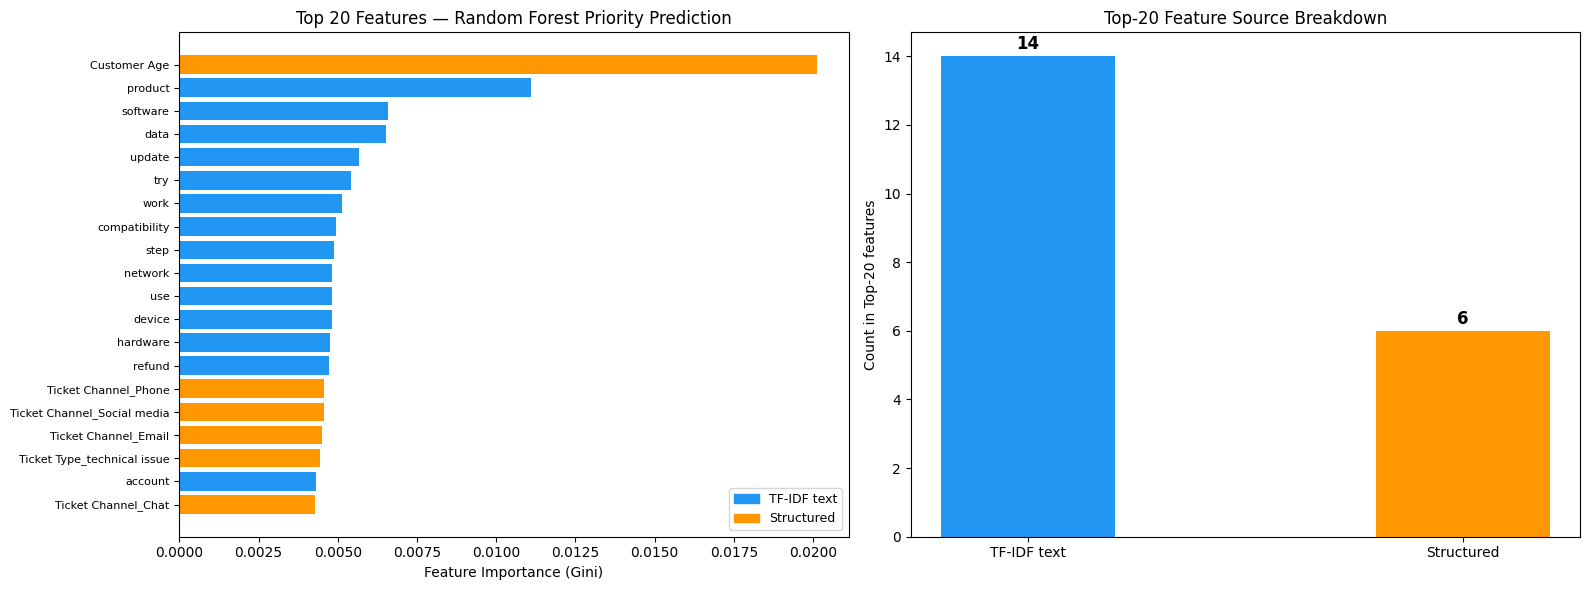

Saved: reports/figures/feature_importance_priority.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colours = ['#2196F3' if s == 'text (TF-IDF)' else '#FF9800' for s in top20['source']]
axes[0].barh(range(20), top20['importance'].values[::-1], color=colours[::-1])
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20['feature'].values[::-1], fontsize=8)
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title('Top 20 Features — Random Forest Priority Prediction')
patch_t = mpatches.Patch(color='#2196F3', label='TF-IDF text')
patch_s = mpatches.Patch(color='#FF9800', label='Structured')
axes[0].legend(handles=[patch_t, patch_s], loc='lower right', fontsize=9)

axes[1].bar(['TF-IDF text', 'Structured'], [text_in_top20, struct_in_top20],
            color=['#2196F3', '#FF9800'], width=0.4)
axes[1].set_ylabel('Count in Top-20 features')
axes[1].set_title('Top-20 Feature Source Breakdown')
for i, v in enumerate([text_in_top20, struct_in_top20]):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_priority.png', dpi=150)
plt.show()
print('Saved: reports/figures/feature_importance_priority.png')

## Step 8 — Full Model Comparison Table

Side-by-side comparison of all model configurations.  
'vs Week 2' shows percentage-point improvement over the Week 2 text-only LinearSVC baseline of 27.3%.

In [10]:
rows = []
for name, r in results.items():
    rows.append({
        'Model':         name,
        'Features':      r['features'],
        'Accuracy':      f"{r['accuracy']:.4f}",
        'Macro F1':      f"{r['macro_f1']:.4f}" if r['macro_f1'] is not None else '—',
        'vs Week 2 (pp)': f"{(r['accuracy'] - WEEK2_TEXT_ONLY_ACC)*100:+.1f}"
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

best_model_name = max(
    {k: v for k, v in results.items() if k != 'Random (4 classes)'},
    key=lambda k: results[k]['accuracy']
)
print(f"\nBest model: {best_model_name} — accuracy {results[best_model_name]['accuracy']:.4f}")

                         Model          Features Accuracy Macro F1 vs Week 2 (pp)
            Random (4 classes)       theoretical   0.2500   0.2500           -2.3
LinearSVC — text only (Week 2)         text only   0.2730        —           +0.0
 LinearSVC — text + structured text + structured   0.2642   0.2629           -0.9
          Random Forest (best) text + structured   0.2543   0.2541           -1.9
                XGBoost (best) text + structured   0.2587   0.2555           -1.4

Best model: LinearSVC — text only (Week 2) — accuracy 0.2730


## Step 9 — Save Artefacts

| File | Purpose |
|---|---|
| `models/priority_model.pkl` | Best priority model — loaded by Streamlit |
| `models/priority_encoder.pkl` | Fitted OneHotEncoder — must match training column order |
| `models/priority_label_encoder.pkl` | Fitted LabelEncoder for integer→class mapping |
| `models/priority_feature_columns.json` | Ordered feature name list — guards against column-order bugs |
| `reports/week3_priority_comparison.csv` | Model comparison table |
| `reports/week3_feature_importance.csv` | Full feature importance scores |

> **Column order file is critical.** Streamlit must assemble a new ticket's feature vector in the identical
> column order used during training. Saving this list explicitly makes that check automatic.

In [11]:
import pathlib

if XGB_AVAILABLE and 'XGBoost (best)' in results:
    rf_acc  = results.get('Random Forest (best)', {}).get('accuracy', 0)
    xgb_acc = results.get('XGBoost (best)',       {}).get('accuracy', 0)
    best_priority_model = best_xgb if xgb_acc >= rf_acc else best_rf
    chosen_name = 'XGBoost' if xgb_acc >= rf_acc else 'Random Forest'
else:
    best_priority_model = best_rf
    chosen_name = 'Random Forest'

print(f'Saving model: {chosen_name}')

joblib.dump(best_priority_model, '../models/priority_model.pkl')
joblib.dump(ohe,                 '../models/priority_encoder.pkl')
joblib.dump(le,                  '../models/priority_label_encoder.pkl')

column_spec = {
    'tfidf_feature_count':      n_tfidf,
    'structured_feature_names': struct_feature_names,
    'categorical_columns':      STRUCT_COLS,
    'numeric_columns':          NUM_COLS,
    'excluded_columns':         ['Ticket Status'],
    'total_features':           len(all_feature_names),
    'chosen_model':             chosen_name
}
with open('../models/priority_feature_columns.json', 'w') as f:
    json.dump(column_spec, f, indent=2)

comparison_df.to_csv('../reports/week3_priority_comparison.csv', index=False)
fi_df.to_csv('../reports/week3_feature_importance.csv', index=False)

print('\nSaved artefacts:')
for p_str in [
    '../models/priority_model.pkl',
    '../models/priority_encoder.pkl',
    '../models/priority_label_encoder.pkl',
    '../models/priority_feature_columns.json',
    '../reports/week3_priority_comparison.csv',
    '../reports/week3_feature_importance.csv',
    '../reports/figures/feature_importance_priority.png',
]:
    p = pathlib.Path(p_str)
    size   = p.stat().st_size / 1024 if p.exists() else 0
    status = f'{size:.1f} KB' if p.exists() else 'MISSING'
    print(f'  {p_str:<55} {status}')

Saving model: XGBoost

Saved artefacts:
  ../models/priority_model.pkl                            573.1 KB
  ../models/priority_encoder.pkl                          2.2 KB
  ../models/priority_label_encoder.pkl                    0.5 KB
  ../models/priority_feature_columns.json                 2.3 KB
  ../reports/week3_priority_comparison.csv                0.3 KB
  ../reports/week3_feature_importance.csv                 64.1 KB
  ../reports/figures/feature_importance_priority.png      82.2 KB
